In [ ]:
import json

with open("../data/json/trainer_state_6epochs_2003.json") as f:
    state = json.load(f)

# Komplette History
log_history = state["log_history"]

# Letzter Eintrag
print(state["log_history"][-1])

# Alle Einträge schön ausgeben
for entry in log_history:
    print(entry)

    import pandas as pd

df = pd.DataFrame(log_history)
df.to_csv("./data/training_histories/training_history_6epochs1.csv", index=False)
print(df)




{'entropy': 1.313095074892044, 'epoch': 5.996245306633291, 'grad_norm': 0.26345309615135193, 'learning_rate': 2.9562728058873947e-10, 'loss': 1.2930147171020507, 'mean_token_accuracy': 0.7253918021917343, 'num_tokens': 67159862.0, 'step': 11980}
{'entropy': 1.9616565227508544, 'epoch': 0.0050062578222778474, 'grad_norm': 2.063286542892456, 'learning_rate': 5e-06, 'loss': 5.158082580566406, 'mean_token_accuracy': 0.3384102150797844, 'num_tokens': 55794.0, 'step': 10}
{'entropy': 1.987595158815384, 'epoch': 0.010012515644555695, 'grad_norm': 2.1318483352661133, 'learning_rate': 1.0555555555555555e-05, 'loss': 5.032905197143554, 'mean_token_accuracy': 0.3471950590610504, 'num_tokens': 111638.0, 'step': 20}
{'entropy': 2.0801442146301268, 'epoch': 0.015018773466833541, 'grad_norm': 1.6422381401062012, 'learning_rate': 1.6111111111111115e-05, 'loss': 4.6456653594970705, 'mean_token_accuracy': 0.38526953011751175, 'num_tokens': 167483.0, 'step': 30}
{'entropy': 2.169314277172089, 'epoch': 0.

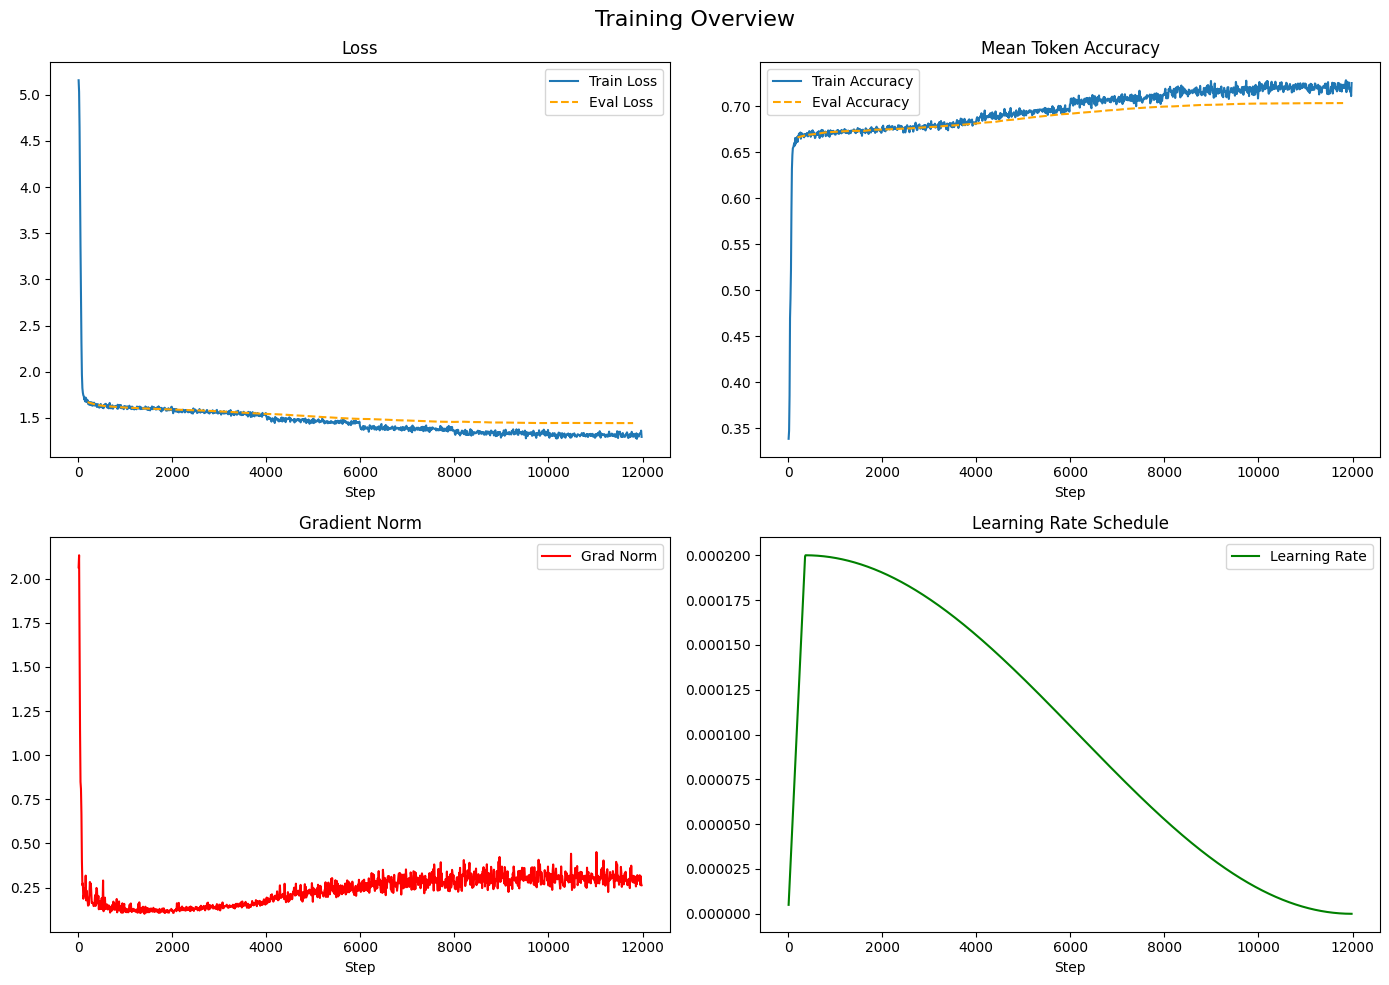

In [2]:
import matplotlib.pyplot as plt
# Train und Eval trennen
train_df = df[df["loss"].notna()]
eval_df = df[df["eval_loss"].notna()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Overview", fontsize=16)

# 1. Loss
ax = axes[0, 0]
ax.plot(train_df["step"], train_df["loss"], label="Train Loss")
ax.plot(eval_df["step"], eval_df["eval_loss"], color="orange", linestyle="--", label="Eval Loss")
ax.set_title("Loss")
ax.set_xlabel("Step")
ax.legend()

# 2. Token Accuracy
ax = axes[0, 1]
ax.plot(train_df["step"], train_df["mean_token_accuracy"], label="Train Accuracy")
ax.plot(eval_df["step"], eval_df["eval_mean_token_accuracy"], color="orange", linestyle="--", label="Eval Accuracy")
ax.set_title("Mean Token Accuracy")
ax.set_xlabel("Step")
ax.legend()

# 3. Grad Norm
ax = axes[1, 0]
ax.plot(train_df["step"], train_df["grad_norm"], label="Grad Norm", color="red")
ax.set_title("Gradient Norm")
ax.set_xlabel("Step")
ax.legend()

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(train_df["step"], train_df["learning_rate"], label="Learning Rate", color="green")
ax.set_title("Learning Rate Schedule")
ax.set_xlabel("Step")
ax.legend()

plt.tight_layout()
plt.savefig("training_overview_6epochs1.png", dpi=150)
plt.show()

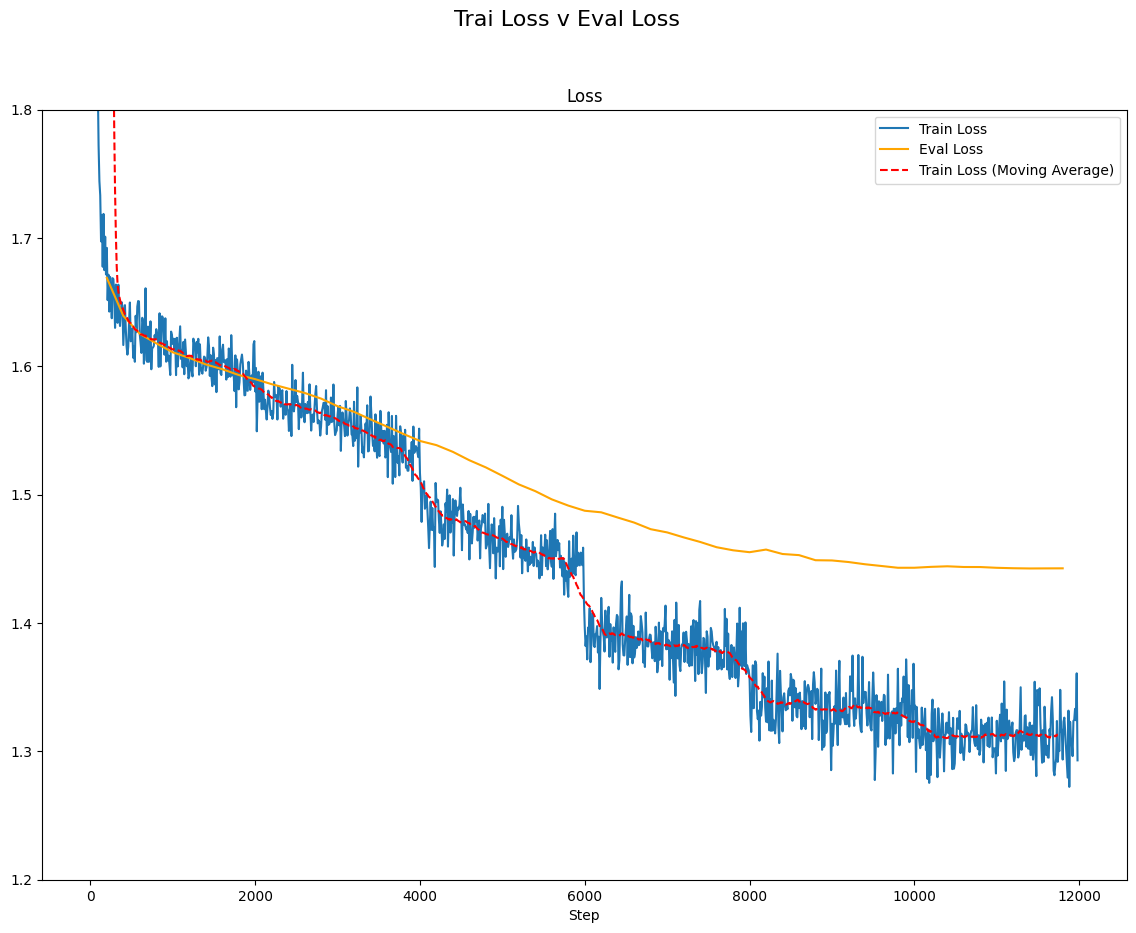

In [4]:
# moving average for entropy loss
window = 50
train_df["Entropy loss (MA)"] = train_df["loss"].rolling(window=window, center = True).mean()


fig, ax = plt.subplots(1, 1, figsize=(14, 10))
fig.suptitle("Trai Loss v Eval Loss", fontsize=16)

# 1. Loss
ax.plot(train_df["step"], train_df["loss"], label="Train Loss")
ax.plot(eval_df["step"], eval_df["eval_loss"], color="orange", linestyle="-", label="Eval Loss")
ax.plot(train_df["step"],train_df["Entropy loss (MA)"], color = "red", linestyle = "--", label = "Train Loss (Moving Average)")
ax.set_title("Loss")
ax.set_xlabel("Step")
ax.set_ylim(1.2,1.8)
ax.legend()

plt.savefig("training_loss_zoom_6epochs1.png", dpi=150)